   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                           3  


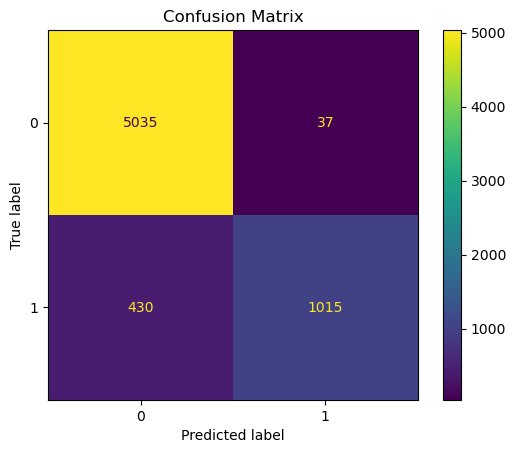

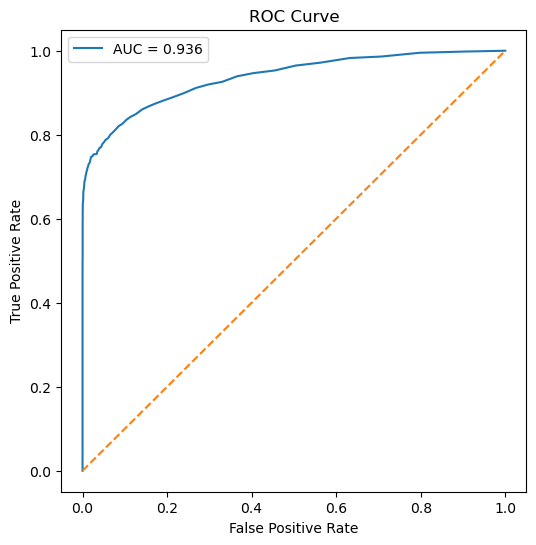

              precision    recall  f1-score   support

           0       0.92      0.99      0.96      5072
           1       0.96      0.70      0.81      1445

    accuracy                           0.93      6517
   macro avg       0.94      0.85      0.88      6517
weighted avg       0.93      0.93      0.92      6517

                  Feature  Importance
11      income_loan_ratio    0.147106
8     loan_percent_income    0.142676
1           person_income    0.111294
5              loan_grade    0.110175
2   person_home_ownership    0.100983
7           loan_int_rate    0.099525
4             loan_intent    0.063087
12       emp_income_ratio    0.057928
6               loan_amnt    0.052681
3       person_emp_length    0.042358


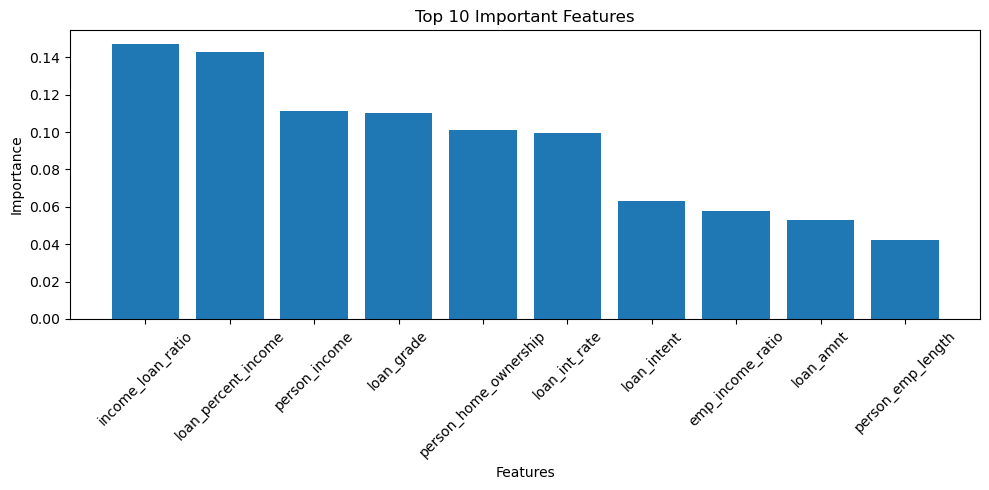

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve
df = pd.read_csv("credit_risk_dataset.csv")

print(df.head())
print(df.shape)
print(df.isnull().sum())
df.fillna(df.mode().iloc[0], inplace=True)
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

print(df.head())
df['income_loan_ratio'] = df['person_income'] / (df['loan_amnt'] + 1)

df['emp_income_ratio'] = df['person_emp_length'] / (df['person_income'] + 1)
X = df.drop('loan_status', axis=1)

y = df['loan_status']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

y_prob = rf.predict_proba(X_test)[:,1]
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC AUC  :", roc_auc)
print(confusion_matrix(y_test, y_pred))

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.title("Confusion Matrix")
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print(classification_report(y_test, y_pred))
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

plt.figure(figsize=(10,5))
plt.bar(
    importance['Feature'][:10],
    importance['Importance'][:10]
)

plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Top 10 Important Features")
plt.tight_layout()
plt.show()